In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from kret_studies import *
from kret_studies.notebook import *
from kret_studies.complex import *

logger = get_notebook_logger()

Loaded environment variables from /Users/Akseldkw/coding/Columbia/RL-Project/.env.


INFO:datasets:JAX version 0.7.2 available.


In [3]:
from waymo_agent import *

In [4]:
G = ox.load_graphml(filepath=MAP_DIR / "manhattan.graphml")

In [5]:
# fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

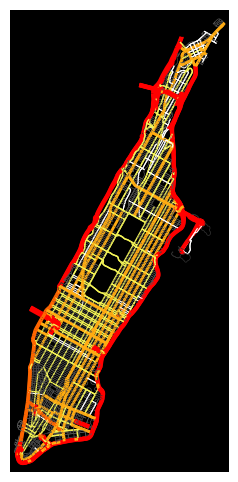

In [ ]:
# 1. Load graph (if not already loaded)
# G = ox.load_graphml("manhattan.graphml")

# 2. Define mappings for Colors AND Widths
config = {
    "motorway": {"color": "#ff0000", "width": 3.0},  # Red, Thickest
    "motorway_link": {"color": "#ff0000", "width": 3.0},
    "trunk": {"color": "#ff6600", "width": 2.5},  # Orange, Thick
    "primary": {"color": "#ffac12", "width": 2.0},  # Gold, Medium-Thick
    "secondary": {"color": "#f4f458", "width": 1.0},  # Yellow, Medium
    "tertiary": {"color": "#ffffff", "width": 0.8},  # White, Thin
    "residential": {"color": "#555555", "width": 0.5},  # Grey, Thinnest
    "default": {"color": "#333333", "width": 0.5},  # Fallback
}

# 3. Generate the lists
edge_colors = []
edge_widths = []

for u, v, data in G.edges(data=True):
    # Get highway type (handle lists if necessary)
    highway_type = data.get("highway", "default")
    if isinstance(highway_type, list):
        highway_type = highway_type[0]

    # Fetch style from config, or use default if type not found
    style = config.get(highway_type, config["default"])

    edge_colors.append(style["color"])
    edge_widths.append(style["width"])

# 4. Plot with both attributes
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,  # <--- Pass the new list here
    bgcolor="black",
    figsize=(6, 6),  # Bigger size helps see the width differences
    show=True,
)

In [7]:
# fig.savefig(IMG_DIR / "manhattan-full-colorful.png", dpi=600, bbox_inches="tight", facecolor=fig.get_facecolor())

In [8]:
len(G.nodes), len(G.edges)

(4619, 9901)

## Sparsify the graph

In [9]:
G = ox.load_graphml(filepath=MAP_DIR / "manhattan.graphml")

In [10]:
G_sparse = sparsify_graph(G)

Removing 4782 non-major edges...
Graph after edge removal: G_sparsified.number_of_nodes()=3505, G_sparsified.number_of_edges()=5117
Cleaning all edge attributes before simplification...
Cleaning list attribute 'reversed' on edge (42421783, 42443522, 0). Original value: [False, True]
Cleaning list attribute 'reversed' on edge (42421985, 42430981, 0). Original value: [False, True]
Cleaning list attribute 'maxspeed' on edge (42428047, 42428049, 0). Original value: ['4 mph', '25 mph']
Cleaning list attribute 'maxspeed' on edge (42428049, 42428047, 0). Original value: ['4 mph', '25 mph']
Cleaning list attribute 'reversed' on edge (42428634, 6207264908, 0). Original value: [False, True]
Cleaning list attribute 'reversed' on edge (42429565, 42429570, 0). Original value: [False, True]
Cleaning list attribute 'reversed' on edge (42429570, 42429565, 0). Original value: [False, True]
Cleaning list attribute 'reversed' on edge (42430633, 42437678, 0). Original value: [False, True]
Cleaning list at

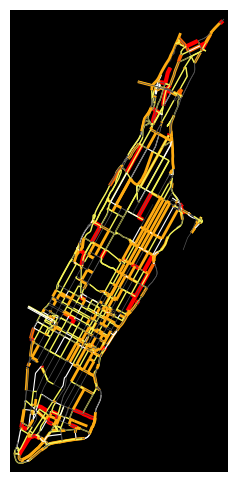

In [ ]:
fig, ax = ox.plot_graph(
    G_sparse,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,  # <--- Pass the new list here
    bgcolor="black",
    figsize=(6, 6),  # Bigger size helps see the width differences
    show=True,
)
fig.savefig(IMG_DIR / "manhattan-sparse-colorful.png", dpi=600, bbox_inches="tight", facecolor=fig.get_facecolor())

In [29]:
from waymo_agent import *

In [ ]:
from waymo_agent.osmnx.inspect import *

In [31]:
max_speed_distribution(G_sparse)

{'25 mph': 1125,
 '20 mph': 203,
 '40 mph': 62,
 '50 mph': 35,
 '30 mph': 60,
 '35 mph': 11,
 '4 mph': 2,
 '45 mph': 21}

In [57]:
inspect(G)

Graph has 4619 nodes and 9901 edges.
Sample node attributes: {'y': 40.7443472, 'x': -73.9713203, 'street_count': 3}

Sample edge attributes: {'osmid': 5672217, 'highway': 'residential', 'maxspeed': '20 mph', 'name': 'Cooper Street', 'oneway': True, 'reversed': False, 'length': 177.68348679429604, 'geometry': <LINESTRING (-73.924 40.868, -73.924 40.868, -73.923 40.868, -73.922 40.868,...>}
